<a href="https://colab.research.google.com/github/Arooj-06/Machine-Learning/blob/main/Day%2031-Function%20Transformer-/Function_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np

import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [7]:
df=pd.read_csv('/content/train.csv',usecols=['Age','Fare','Survived'])

In [8]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [9]:
#age has missing values
df['Age'].fillna(df['Age'].mean(),inplace=True)


/tmp/ipykernel_1742/291465324.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [10]:
df.isnull().sum()

,0
Survived,0
Age,0
Fare,0


In [15]:
X=df[['Age','Fare']]

In [14]:
y=df['Survived']

In [16]:
X_train, X_test , y_train ,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

/tmp/ipykernel_1742/3593427296.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'])


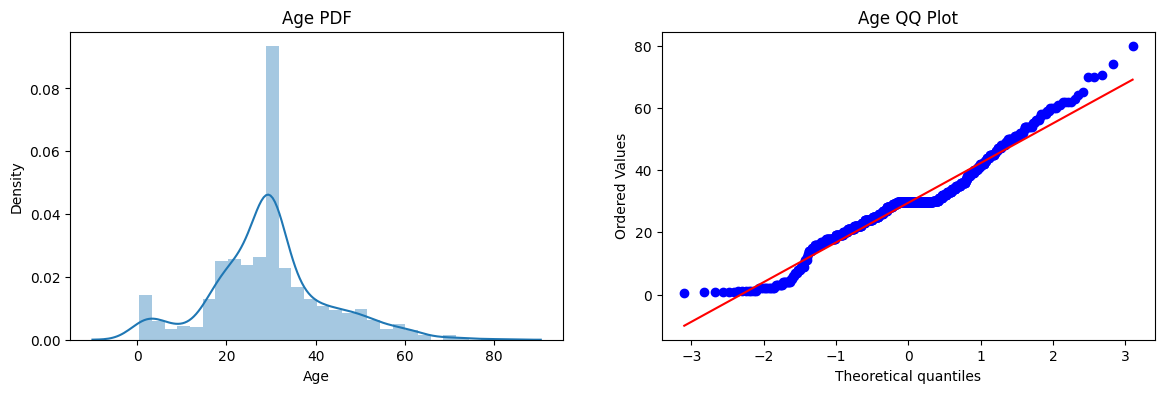

In [17]:
#plotting and see if the data is normally ditrubuted or not
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Age'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'],dist="norm",plot=plt)
plt.title('Age QQ Plot')

plt.show()

In [ ]:
#age is not a perfect normally distributed

/tmp/ipykernel_1742/2877834621.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'])


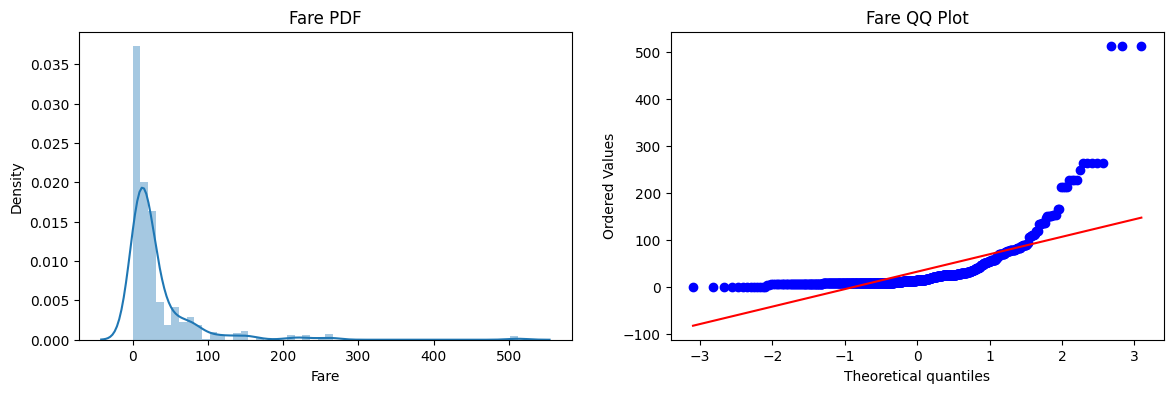

In [18]:
#plotting and see if the data is normally ditrubuted or not
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Fare'])
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'],dist="norm",plot=plt)
plt.title('Fare QQ Plot')

plt.show()

In [ ]:
#fare is right skewed

In [19]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()
#i made objects of these models

In [22]:
#we will train the model with the not normally distributued data
# and find the accuracy

clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)

y_pred=clf.predict(X_test)
y_pred2=clf2.predict(X_test)

print(accuracy_score(y_test,y_pred))
print(accuracy_score(y_test,y_pred2))

0.6480446927374302
0.6927374301675978


In [23]:
#now apply feature transformations
#to normally distribute the data

#LOG FUNCTION
#diff in np.log and np.log1 is written in the register notes
trf=FunctionTransformer(np.log1p)

In [25]:
#now we transform teh AGE and FARE
X_train_transformed=trf.fit_transform(X_train)
X_test_transformed=trf.transform(X_test)

In [26]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

In [31]:
clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)

DecisionTreeClassifier()

In [32]:
y_pred=clf.predict(X_test_transformed)
y_pred2=clf2.predict(X_test_transformed)

print(accuracy_score(y_test,y_pred))
print(accuracy_score(y_test,y_pred2))

0.6815642458100558
0.659217877094972


In [ ]:
#logictric regression ki accuracy py fark pry ga after transforming
#decision tree py nhi fark prta


**CROSS_VALIDATION**

In [33]:
X_transformed=trf.fit_transform(X)

In [35]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed,y,cv=10,scoring='accuracy')))
print("DT",np.mean(cross_val_score(clf2,X_transformed,y,cv=10,scoring='accuracy')))

LR 0.678027465667915
DT 0.6554681647940075


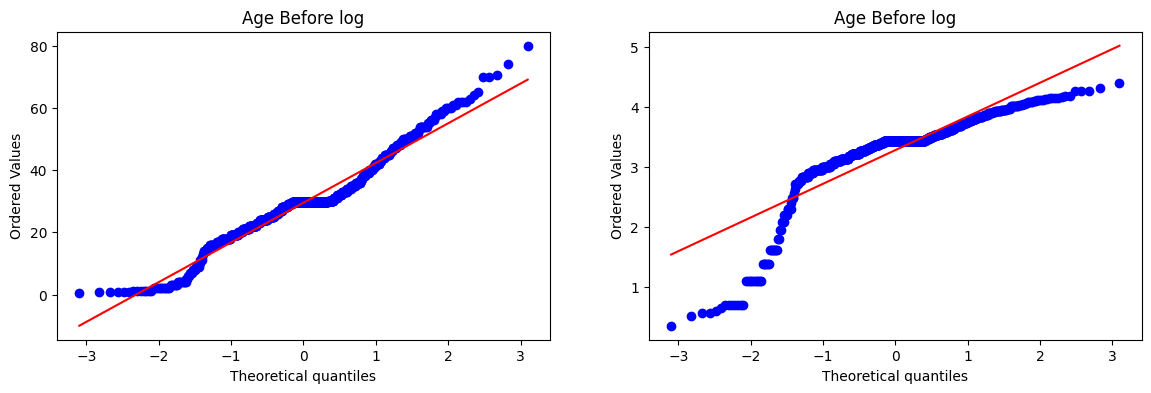

In [41]:
#plotting AGE before and after trans
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Age'],dist='norm',plot=plt)
plt.title('Age Before log')


plt.subplot(122)
stats.probplot(X_train_transformed['Age'],dist='norm',plot=plt)
plt.title('Age Before log')

plt.show()

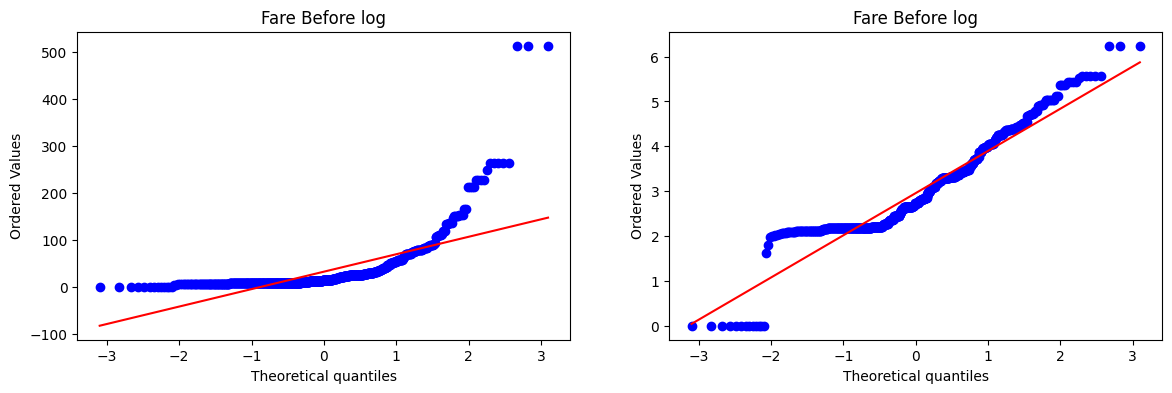

In [42]:
#plotting Fare
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Fare'],dist='norm',plot=plt)
plt.title('Fare Before log')


plt.subplot(122)
stats.probplot(X_train_transformed['Fare'],dist='norm',plot=plt)
plt.title('Fare Before log')

plt.show()